### Description
This notebook serves as a central place to experiment with GPKoopman class features in a local definition envrionment before placing said features into the actual package itself.

#### Package import

In [1]:
import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import math
import time
import torch.nn.functional as F  # For softplus transformation

## Local GPObs Definition and Testing

### Kernels

In [2]:
def GaussianKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)**2
    return hp1 * torch.exp(-dists / (2 * hp2**2))


def ThinSplineKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)
    epsilon = 1e-8
    return hp1 * ((dists/hp2)**2) * torch.log((dists / hp2) + epsilon)


def InverseQuadraticKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)**2
    return hp1 * (1 / (1 + (dists / (hp2**2))))


def CosineKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)
    return hp1 * torch.cos(math.pi * dists / hp2) ** 2


def ExpSineSqrKernel(X1, X2, hp1, hp2):
    dists = torch.cdist(X1.T, X2.T, p=2)
    hp2 = torch.clamp(hp2, min=1e-2)
    epsilon = 1e-4
    return hp1 * torch.exp(epsilon - 0.5 * ((torch.sin(math.pi * dists / hp1)) ** 2) / hp2)
    # return torch.exp((-2 * (torch.sin(math.pi * dists / hp1))**2) / hp2**2)


def GibbsExpAttractorKernel(X1, X2, hp1, hp2, mu):
    """
    Gibbs kernel with an attractor-dependent exponential decay length scale.
    The length scale decreases with distance from the attractor.

    Args:
        X1 (Tensor): First set of points (d, n1).
        X2 (Tensor): Second set of points (d, n2).
        hp1 (Tensor): Scaling factor for the length scale.
        hp2 (Tensor): Baseline length scale.
        mu (Tensor): Location of the attractor (d, 1).

    Returns:
        Tensor: Kernel matrix of shape (n1, n2).
    """
    # Shift inputs by the attractor location
    # X1_shifted = X1 - mu.unsqueeze(1)  # (d, n1)
    # X2_shifted = X2 - mu.unsqueeze(1)  # (d, n2)
    X1_shifted = X1 - mu
    X2_shifted = X2 - mu

    # Compute squared norm relative to attractor
    X1_norm2 = torch.sum(X1_shifted**2, dim=0)  # (n1,)
    X2_norm2 = torch.sum(X2_shifted**2, dim=0)  # (n2,)

    # Compute input-dependent length scales
    l_X1 = hp1 + hp2 * torch.exp(-X1_norm2)  # (n1,)
    l_X2 = hp1 + hp2 * torch.exp(-X2_norm2)  # (n2,)

    # Compute Gibbs kernel denominator
    L_sum = (l_X1**2).unsqueeze(1) + (l_X2**2).unsqueeze(0)  # (n1, n2)
    outer_l = l_X1.unsqueeze(1) * l_X2.unsqueeze(0)  # (n1, n2)
    factor = torch.sqrt(2.0 * outer_l / L_sum)

    # Compute squared Euclidean distances
    dists = torch.cdist(X1.T, X2.T, p=2)**2  # (n1, n2)

    # Compute kernel matrix
    return factor * torch.exp(-dists / L_sum)


def ExplicitAttractorKernel(X1, X2, hp1, hp2, mu):
    """
    Computes the Explicit Kernel K_Explicit(x, x') for attractor-based covariance.

    Args:
        X1 (Tensor): First set of points (d, n1).
        X2 (Tensor): Second set of points (d, n2).
        hp1 (Tensor): Scaling factor (theta_1).
        hp2 (Tensor): Length scale (theta_2).
        mu (Tensor): Location of the attractor (d, 1).

    Returns:
        Tensor: Kernel matrix (n1, n2).
    """
    # Compute squared distances from the attractor for X1 and X2
    X1_shifted_norm2 = torch.sum((X1 - mu) ** 2, dim=0)  # (n1,)
    X2_shifted_norm2 = torch.sum((X2 - mu) ** 2, dim=0)  # (n2,)

    # Compute the exponent term
    exponent = -(X1_shifted_norm2.unsqueeze(1) + X2_shifted_norm2.unsqueeze(0)) / (2 * hp2**2)

    # Compute the kernel matrix
    return hp1 * torch.exp(exponent)



# Dictionary mapping kernel names to functions
KERNEL_FUNCTIONS = {
    'Gaussian': GaussianKernel,
    'ThinSpline': ThinSplineKernel,
    'InverseQuadratic': InverseQuadraticKernel,
    'ExpSineSqr': ExpSineSqrKernel,
    'Cosine': CosineKernel,
    'GibbsExpAttractor': GibbsExpAttractorKernel,
    'ExplicitAttractor': ExplicitAttractorKernel
}


def KernelFunction(X1, X2=None, kernel_types=['Gaussian'], hp1_list=None, hp2_list=None, mu_list=None, combination='sum'):
    """
    Computes a kernel matrix using multiple kernels, supporting attractor-based kernels.

    Args:
        X1 (Tensor): First set of points.
        X2 (Tensor, optional): Second set of points. Defaults to None.
        kernel_types (list): List of kernel function names.
        hp1_list (list, optional): List of first hyperparameters for each kernel.
        hp2_list (list, optional): List of second hyperparameters for each kernel.
        mu_list (list, optional): List of attractor locations for each kernel.
        combination (str): How to combine kernels ('sum' or 'product').

    Returns:
        Tensor: Kernel matrix.
    """
    if X2 is None:
        X2 = X1

    if hp1_list is None:
        hp1_list = [torch.tensor(1.0, device=X1.device)] * len(kernel_types)
    if hp2_list is None:
        hp2_list = [torch.tensor(1.0, device=X1.device)] * len(kernel_types)
    if mu_list is None:
        mu_list = [None] * len(kernel_types)

    if len(hp1_list) != len(kernel_types) or len(hp2_list) != len(kernel_types) or len(mu_list) != len(kernel_types):
        raise ValueError("Number of hyperparameters and attractor locations must match the number of kernel types.")

    # Compute the kernel matrix
    if combination == 'sum':
        K = sum(KERNEL_FUNCTIONS[kernel](X1, X2, hp1, hp2, mu)
                if mu is not None else KERNEL_FUNCTIONS[kernel](X1, X2, hp1, hp2)
                for kernel, hp1, hp2, mu in zip(kernel_types, hp1_list, hp2_list, mu_list))
    elif combination == 'product':
        K = torch.ones((X1.shape[1], X2.shape[1]), device=X1.device)
        for kernel, hp1, hp2, mu in zip(kernel_types, hp1_list, hp2_list, mu_list):
            if mu is not None:
                K *= KERNEL_FUNCTIONS[kernel](X1, X2, hp1, hp2, mu)
            else:
                K *= KERNEL_FUNCTIONS[kernel](X1, X2, hp1, hp2)
    else:
        raise ValueError("Invalid combination method. Choose 'sum' or 'product'.")

    return K


#### Kernel-Only Testing

In [3]:
# Define 1D grid of values for x and x'
x_start, x_end = -5, 5
x_vals = torch.linspace(x_start, x_end, 100).view(1, -1)  # (1, 100)
x_prime_vals = torch.linspace(x_start, x_end, 100).view(1, -1)  # (1, 100)

# Define hyperparameters and attractor location
hp1 = torch.tensor(0.1)  # Baseline length scale
hp2 = torch.tensor(1.)  # Scale factor for length scale function
mu = torch.tensor(2.)  # Attractor location (1D)

# Compute covariance matrix
#K1 = GibbsExpAttractorKernel(x_vals, x_prime_vals, hp1, hp2, mu).detach().numpy()
K1 = KernelFunction(X1=x_vals, X2=x_prime_vals, kernel_types=['GibbsExpAttractor'], hp1_list=[hp1], hp2_list=[hp2], mu_list=[mu])
K2 = KernelFunction(X1=x_vals, X2=x_prime_vals, kernel_types=['ExplicitAttractor'], hp1_list=[hp1], hp2_list=[hp2], mu_list=[mu])
K3 = KernelFunction(X1=x_vals, X2=x_prime_vals, kernel_types=['Gaussian'], hp1_list=[hp1], hp2_list=[hp2], mu_list=None)
K4 = KernelFunction(X1=x_vals, X2=x_prime_vals, kernel_types=['ThinSpline'], hp1_list=[hp1], hp2_list=[hp2], mu_list=None)

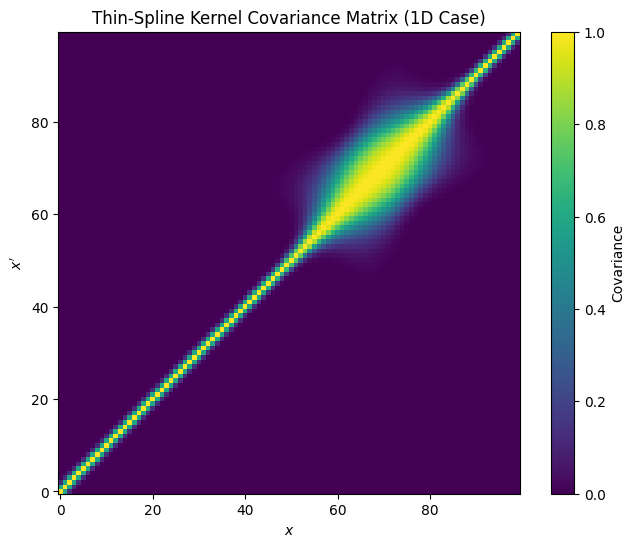

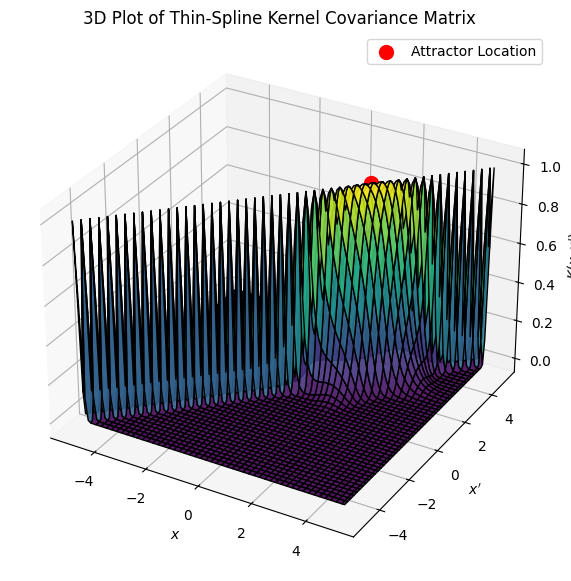

In [4]:
K = K1
# Plot the covariance heatmap
plt.figure(figsize=(8, 6))
plt.imshow(K, origin='lower', cmap='viridis')
plt.colorbar(label="Covariance")
plt.xlabel("$x$")
plt.ylabel("$x'$")
plt.title("Thin-Spline Kernel Covariance Matrix (1D Case)")
plt.show()

# Convert tensors to numpy arrays for plotting
X, Y = np.meshgrid(x_vals.numpy().flatten(), x_prime_vals.numpy().flatten())

# Create 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, K, cmap='viridis', edgecolor='k', alpha=0.9)

# Mark the attractor location
ax.scatter(mu.numpy(), mu.numpy(), GibbsExpAttractorKernel(mu.view(1, 1), mu.view(1, 1), hp1, hp2, mu).item(), 
           color='red', s=100, label="Attractor Location")

# Labels and title
ax.set_xlabel("$x$")
ax.set_ylabel("$x'$")
ax.set_zlabel("$K(x, x')$")
ax.set_title("3D Plot of Thin-Spline Kernel Covariance Matrix")
ax.legend()

plt.show()

### Class Definition - GPObservable

In [5]:
class GPObservable:
    count = 0

    def __init__(self, d, ns, kernel_types=['Gaussian'], hp1_list=None, hp2_list=None,
                 mu_list=None, noise=2e-8, combination='sum', device='cuda:0', m=200):
        """
        Gaussian Process Observable with customizable kernel functions.

        Args:
            d (int): Dimensionality of the inputs.
            ns (int): Number of training samples.
            kernel_types (list): List of kernel names.
            hp1_list (list): List of first hyperparameters for each kernel.
            hp2_list (list): List of second hyperparameters for each kernel.
            noise (float): Observation noise.
            combination (str): Kernel combination method ('sum' or 'product').
            device (str): Compute device ('cuda:0' or 'cpu').
        """
        self.device = torch.device(device)
        self.kernel_types = kernel_types  # List of kernel functions
        self.combination = combination  # How kernels are combined

        # Ensure hyperparameter lists are set correctly
        self.hp1_list = hp1_list if hp1_list is not None else [torch.tensor(
            1.0, requires_grad=True, device=self.device) for _ in kernel_types]
        self.hp2_list = hp2_list if hp2_list is not None else [torch.tensor(
            1.0, requires_grad=True, device=self.device) for _ in kernel_types]
        
        self.uses_mu = any(k in ['GibbsExpAttractor', 'ExplicitAttractor'] for k in kernel_types)

        if self.uses_mu:
            self.mu_list = mu_list if mu_list is not None else [torch.zeros((d, 1), requires_grad=True, device=self.device) for _ in kernel_types]
        else:
            self.mu_list = None
        
        if len(self.hp1_list) != len(kernel_types) or len(self.hp2_list) != len(kernel_types):
            raise ValueError(
                "Number of hyperparameters must match the number of kernel types.")

        # self.noise = torch.tensor(
        #     noise, requires_grad=True, device=self.device)

        self.noise = torch.nn.Parameter(torch.tensor(noise, device=self.device))

        self.m = min(m, ns)
        # self.idx_SOR = torch.linspace(0, ns-1, m).int()
        self.idx_SOR = torch.linspace(0, ns-1, m).int()
        self.Xm = torch.empty((m, m), device=self.device)
        self.Knm = torch.empty((ns, m), device=self.device)
        self.y = torch.empty((ns, 1), device=self.device)  # Target values
        # SOR trained coefficient
        self.aSOR = torch.empty((ns, 1), device=self.device)
        GPObservable.count += 1

    def set_hyperparameters(self, hp1_list=None, hp2_list=None):
        if hp1_list is not None:
            self.hp1_list = [torch.tensor(
                hp, requires_grad=True, device=self.device) for hp in hp1_list]
        if hp2_list is not None:
            self.hp2_list = [torch.tensor(
                hp, requires_grad=True, device=self.device) for hp in hp2_list]

    def trainGP(self, Xtrain, ytrain):
        Xtrain = Xtrain.to(self.device)
        ytrain = ytrain.to(self.device)
        self.Xtrain = Xtrain
        self.y = ytrain

        self.Xm = Xtrain[:, self.idx_SOR]

        self.Kmm = KernelFunction(self.Xm, self.Xm, kernel_types=self.kernel_types,
                                  hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                                  mu_list=self.mu_list, combination=self.combination)
        self.Kmn = KernelFunction(self.Xm, self.Xtrain, kernel_types=self.kernel_types,
                                  hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                                  mu_list=self.mu_list, combination=self.combination)

        try:
            L = torch.linalg.cholesky(
                (self.Kmn @ self.Kmn.T) + ((self.noise)**2)*self.Kmm)
            self.invKmm = torch.cholesky_inverse(L)
        except RuntimeError:
            U, S, V = torch.linalg.svd(
                (self.Kmn @ self.Kmn.T) + ((self.noise)**2)*self.Kmm)
            S_inv = torch.diag(torch.where(
                S > 1e-6, 1.0 / S, torch.tensor(0.0, device=self.device)))
            self.invKmm = V.T @ S_inv @ U.T

        self.alpha = self.invKmm @ self.Kmn @ self.y

    def predictGP(self, Xq):
        Kqm = KernelFunction(Xq, self.Xm, kernel_types=self.kernel_types,
                             hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                             mu_list=self.mu_list, combination=self.combination)
        
        mean = Kqm @ self.alpha
        CovMat = (Kqm @ self.invKmm @ torch.t(Kqm)) * (self.noise ** 2)
        return mean, CovMat

    def predictMean(self, Xq):
        Kqm = KernelFunction(Xq, self.Xm, kernel_types=self.kernel_types,
                             hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                             mu_list=self.mu_list, combination=self.combination)
        return Kqm @ self.alpha

    def predictCov(self, Xq):
        Kqm = KernelFunction(Xq, self.Xm, kernel_types=self.kernel_types,
                             hp1_list=self.hp1_list, hp2_list=self.hp2_list,
                             mu_list=self.mu_list, combination=self.combination)
        # Kqq = KernelFunction(Xq, Xq, kernel_types=self.kernel_types,
        #                      hp1_list=self.hp1_list, hp2_list=self.hp2_list,
        #                      combination=self.combination)
        return (Kqm @ self.invKmm @ torch.t(Kqm)) * (self.noise ** 2)

   
    def optimize_hyperparameters(self, max_iter=100, lr=0.01):
        if not hasattr(self, 'Xtrain') or not hasattr(self, 'y'):
            raise ValueError(
                "Training data not found. Please call trainGP before optimizing hyperparameters.")

        # Store original references
        orig_hp1_list = self.hp1_list
        orig_hp2_list = self.hp2_list
        orig_noise = self.noise

        # Create transformed versions for optimization
        opt_hp1_list = [torch.nn.Parameter(torch.nn.functional.softplus(hp.detach())) for hp in orig_hp1_list]
        opt_hp2_list = [torch.nn.Parameter(torch.nn.functional.softplus(hp.detach())) for hp in orig_hp2_list]
        opt_noise = torch.nn.Parameter(torch.nn.functional.softplus(orig_noise.detach()))

        optimizer = torch.optim.Adam([*opt_hp1_list, *opt_hp2_list, opt_noise], lr=lr)

        for _ in range(max_iter):
            optimizer.zero_grad()

            # Convert softplus-transformed params back
            hp1_opt = [torch.nn.functional.softplus(hp) for hp in opt_hp1_list]
            hp2_opt = [torch.nn.functional.softplus(hp) for hp in opt_hp2_list]
            noise_opt = torch.nn.functional.softplus(opt_noise)

            # Compute Kernel Inversion with jitter for stability
            jitter = 1e-6 * torch.eye(self.Xm.shape[1], device=self.device)
            iKmm = torch.linalg.inv(KernelFunction(self.Xm, self.Xm, kernel_types=self.kernel_types,
                                                hp1_list=hp1_opt, hp2_list=hp2_opt,
                                                mu_list=self.mu_list, combination=self.combination) + jitter)

            Kmn = KernelFunction(self.Xm, self.Xtrain, kernel_types=self.kernel_types,
                                hp1_list=hp1_opt, hp2_list=hp2_opt,
                                mu_list=self.mu_list, combination=self.combination)

            K_til = Kmn.T @ iKmm @ Kmn
            K_til += (noise_opt**2) * torch.eye(K_til.shape[0], device=self.device)
            invK_til = torch.linalg.inv(K_til)

            log_det = torch.logdet(K_til)
            ll = -0.5 * (self.y.T @ invK_til @ self.y + log_det + self.y.shape[0] * torch.log(torch.tensor(2 * torch.pi)))

            loss = -ll.squeeze()
            loss.backward()
            optimizer.step()

        # Restore optimized hyperparameters to original storage
        self.hp1_list = [hp.detach() for hp in hp1_opt]
        self.hp2_list = [hp.detach() for hp in hp2_opt]
        self.noise = noise_opt.detach()

        # Retrain with updated parameters
        self.trainGP(self.Xtrain, self.y)


    @classmethod
    def count_Observables(cls):
        return cls.count


#### Class Testing 1 - GPObservable

In [ ]:
# === Step 1: Define Training Data ===
x_train = torch.linspace(-5, 5, 50).view(1, -1)  # 1D input points (1, 50)
y_train = (torch.sin(x_train) + 0.1 * torch.randn_like(x_train)).T  # Noisy sine function

# === Step 2: Define Hyperparameters and Attractor Location ===
# hp1 = torch.tensor(0.1, requires_grad=True)
# hp2 = torch.tensor(1.0, requires_grad=True)
# mu = torch.tensor(2.0, requires_grad=True).view(1, 1)  # Attractor location (1,1)
hp1 = torch.nn.Parameter(torch.tensor(0.1))  # Now a leaf tensor
hp2 = torch.nn.Parameter(torch.tensor(0.1))
mu = torch.nn.Parameter(torch.tensor(2.0).view(1, 1))  # Reshape while keeping leaf status


# === Step 3: Create a GPObservable Object ===
gp_obs = GPObservable(
    d=1, ns=50, kernel_types=['GibbsExpAttractor'], 
    hp1_list=[hp1], hp2_list=[hp2], mu_list=[mu],
    noise=0.05, combination='sum', device='cpu'
)

# Train GP model
gp_obs.trainGP(x_train, y_train)

# === Step 4: Make Predictions ===
x_test = torch.linspace(-6, 6, 100).view(1, -1)  # Test input points
mean_pred, cov_pred = gp_obs.predictGP(x_test)

# === Step 5: Plot Predictions ===
plt.figure(figsize=(8, 6))
plt.plot(x_train.numpy().flatten(), y_train.numpy().flatten(), 'ro', label="Training Data")
plt.plot(x_test.numpy().flatten(), mean_pred.detach().numpy().flatten(), 'b-', label="GP Mean Prediction")
plt.fill_between(
    x_test.numpy().flatten(),
    (mean_pred - 2 * torch.sqrt(torch.diag(cov_pred).view(-1,1))).view(-1,).detach().numpy(),
    (mean_pred + 2 * torch.sqrt(torch.diag(cov_pred).view(-1,1))).view(-1,).detach().numpy(),
    color='blue', alpha=0.2, label="Confidence Interval"
)
plt.axvline(mu.item(), color='r', linestyle="--", label="Attractor Location")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("GPObservable Prediction with GibbsExpAttractor Kernel")
plt.show()

# === Step 6: Hyperparameter Optimization ===
torch.autograd.set_detect_anomaly(True)

optimizer = torch.optim.Adam([hp1, mu, gp_obs.noise], lr=0.0001)
for step in range(100):
    optimizer.zero_grad()
    
    # Apply Softplus to ensure positivity
    hp1_transformed = torch.nn.functional.softplus(hp1)
    #hp2_transformed = torch.nn.functional.softplus(hp2)
    noise_transformed = torch.nn.functional.softplus(gp_obs.noise)

    # Set the transformed values before passing them into GPObservable
    gp_obs.hp1_list = [hp1_transformed]
    #gp_obs.hp2_list = [hp2_transformed]
    gp_obs.noise = noise_transformed

    # Compute loss
    loss = torch.mean((gp_obs.predictMean(x_train) - y_train) ** 2)  # Mean Squared Error
    if torch.isnan(gp_obs.invKmm).any():
        print("NaN detected in inverse covariance matrix!")
        break

    # Check for NaNs
    if torch.isnan(loss):
        print("NaN detected in loss, stopping optimization.")
        break
    
    loss.backward()
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step}: Loss = {loss.item()}, hp1 = {hp1_transformed.item()}, hp2 = {hp2_transformed.item()}, noise = {noise_transformed.item()}")
        
print("Final optimized parameters:", hp1.item(), hp2.item(), mu.item())

# === Step 7: Recompute and Plot After Optimization ===
mean_pred, cov_pred = gp_obs.predictGP(x_test)

plt.figure(figsize=(8, 6))
plt.plot(x_train.numpy().flatten(), y_train.numpy().flatten(), 'ro', label="Training Data")
plt.plot(x_test.numpy().flatten(), mean_pred.detach().numpy().flatten(), 'b-', label="Optimized GP Mean Prediction")
plt.fill_between(
    x_test.numpy().flatten(),
    (mean_pred - 2 * torch.sqrt(torch.diag(cov_pred))).detach().numpy().flatten(),
    (mean_pred + 2 * torch.sqrt(torch.diag(cov_pred))).detach().numpy().flatten(),
    color='blue', alpha=0.2, label="Optimized Confidence Interval"
)
plt.axvline(mu.item(), color='r', linestyle="--", label="Optimized Attractor Location")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("GPObservable Prediction After Hyperparameter Optimization")
plt.show()


In [ ]:
# === Step 1: Define Training Data ===
x_train = torch.linspace(-10, 10, 50).view(1, -1)  # 1D input points (1, 50)
y_train = torch.sin(x_train.T) + 0.1 * torch.randn_like(x_train.T)  # Noisy sine function

# === Step 2: Define Hyperparameters ===
hp1 = torch.nn.Parameter(torch.tensor(1.0))  # Amplitude
hp2 = torch.nn.Parameter(torch.tensor(0.1))  # Length scale
noise = torch.nn.Parameter(torch.tensor(0.05))  # Observation noise

# === Step 3: Create GPObservable with Gaussian Kernel ===
gp_obs = GPObservable(
    d=1, ns=50, kernel_types=['Gaussian'], 
    hp1_list=[hp1], hp2_list=[hp2],
    noise=noise, combination='sum', device='cpu'
)

# Train GP model
gp_obs.trainGP(x_train, y_train)

# === Step 4: Make Predictions ===
x_test = torch.linspace(-12, 12, 100).view(1, -1)  # Test input points
mean_pred, cov_pred = gp_obs.predictGP(x_test)

# === Step 5: Plot Predictions ===
plt.figure(figsize=(8, 6))
plt.plot(x_train.numpy().flatten(), y_train.numpy().flatten(), 'ro', label="Training Data")
plt.plot(x_test.numpy().flatten(), mean_pred.detach().numpy().flatten(), 'b-', label="GP Mean Prediction")
plt.fill_between(
    x_test.numpy().flatten(),
    (mean_pred - 2 * torch.sqrt(torch.diag(cov_pred).view(-1,1))).view(-1,).detach().numpy(),
    (mean_pred + 2 * torch.sqrt(torch.diag(cov_pred).view(-1,1))).view(-1,).detach().numpy(),
    color='blue', alpha=0.2, label="Confidence Interval"
)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("GPObservable Prediction with Gaussian Kernel")
plt.show()

# === Step 6: Hyperparameter Optimization ===
torch.autograd.set_detect_anomaly(True)  # Enable debugging

optimizer = torch.optim.Adam([hp1, hp2, noise], lr=0.01)

for step in range(100):
    optimizer.zero_grad()

    # Apply Softplus transformation to ensure positivity
    hp1_transformed = F.softplus(hp1) + 1e-6
    hp2_transformed = F.softplus(hp2) + 1e-6
    noise_transformed = F.softplus(noise) + 1e-6

    # Assign transformed values to GPObservable
    gp_obs.hp1_list = [hp1_transformed]
    gp_obs.hp2_list = [hp2_transformed]
    gp_obs.noise = noise_transformed

    # Compute loss
    loss = torch.mean((gp_obs.predictMean(x_train) - y_train) ** 2)

    # Check for NaNs before backward
    if torch.isnan(loss):
        print("NaN detected in loss, stopping optimization.")
        break

    loss.backward()
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step}: Loss = {loss.item()}, hp1 = {hp1_transformed.item()}, hp2 = {hp2_transformed.item()}, noise = {noise_transformed.item()}")

# === Step 7: Recompute and Plot After Optimization ===
mean_pred, cov_pred = gp_obs.predictGP(x_test)

plt.figure(figsize=(8, 6))
plt.plot(x_train.numpy().flatten(), y_train.numpy().flatten(), 'ro', label="Training Data")
plt.plot(x_test.numpy().flatten(), mean_pred.detach().numpy().flatten(), 'b-', label="Optimized GP Mean Prediction")
plt.fill_between(
    x_test.numpy().flatten(),
    (mean_pred - 2 * torch.sqrt(torch.diag(cov_pred).view(-1,1))).view(-1,).detach().numpy(),
    (mean_pred + 2 * torch.sqrt(torch.diag(cov_pred).view(-1,1))).view(-1,).detach().numpy(),
    color='blue', alpha=0.2, label="Optimized Confidence Interval"
)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("GPObservable Prediction After Hyperparameter Optimization (Gaussian Kernel)")
plt.show()

C:\Users\abhig\AppData\Local\Temp\ipykernel_12276\2027674186.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.noise = torch.nn.Parameter(torch.tensor(noise, device=self.device))


IndexError: index 5 is out of bounds for dimension 0 with size 5

In [ ]:
(mean_pred - 2 * torch.sqrt(torch.diag(cov_pred).view(-1,1))).view(-1,)

### Class Definition 2 - GPObservablesManager

In [ ]:
class GPObservablesManager:
    def __init__(self):
        self.observables = {}

    def add_observable(self, index, d, ns, kernel_types=['Gaussian'], hp1_list=None, hp2_list=None, noise=2e-6, combination='sum', m=200):
        if index in self.observables:
            raise ValueError(f'Observable with index {index} already exists.')
        self.observables[index] = GPObservable(
            d, ns, kernel_types, hp1_list, hp2_list, noise, combination, m=m)

    def get_all_parameters(self):
        hp1_list, hp2_list, noise_list, mu_list = [], [], [], []
        for obs in self.observables.values():
            hp1_list.extend(obs.hp1_list)
            hp2_list.extend(obs.hp2_list)
            noise_list.append(obs.noise)
            if obs.uses_mu:
                mu_list.extend(obs.mu_list)
        return hp1_list, hp2_list, noise_list, mu_list if mu_list else None
    
    def set_parameters(self, hp1_list=None, hp2_list=None, noise_list=None, mu_list=None):
        i = 0
        for obs in self.observables.values():
            num_kernels = len(obs.kernel_types)

            if hp1_list is not None:
                for k in range(num_kernels):
                    obs.hp1_list[k].data = hp1_list[i + k].data  # Update in-place
            if hp2_list is not None:
                for k in range(num_kernels):
                    obs.hp2_list[k].data = hp2_list[i + k].data
            if noise_list is not None:
                obs.noise.data = noise_list[i].data
            if mu_list is not None and obs.uses_mu:
                for k in range(num_kernels):
                    obs.mu_list[k].data = mu_list[i + k].data

            i += num_kernels

    def set_random_hyperparameters(self, seed=42, scale=1.0):
        """
        Assigns random hyperparameters (hp1 and hp2) to all observables.

        Args:
            seed (int): Seed for reproducibility.
            scale (float): Scaling factor for the generated hyperparameters.
        """
        torch.manual_seed(seed)  # Set random seed for reproducibility

        for obs in self.observables.values():
            num_kernels = len(obs.kernel_types)

            # Assign random values to hp1 and hp2 lists
            obs.hp1_list = [
                scale * torch.rand(1, device=obs.device, requires_grad=True) for _ in range(num_kernels)]
            obs.hp2_list = [
                scale * torch.rand(1, device=obs.device, requires_grad=True) for _ in range(num_kernels)]

    def train_observable(self, index, Xtrain, ytrain):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        self.observables[index].trainGP(Xtrain, ytrain)

    def predict_mean(self, index, Xq):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        return self.observables[index].predictMean(Xq)

    def predict_covariance(self, index, Xq):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        return self.observables[index].predictCov(Xq)

    def optimize_hyperparameters(self, max_iter=100, lr=0.01):
        for obs in self.observables.values():
            obs.optimize_hyperparameters(max_iter, lr)

    def get_params(self, index):
        if index not in self.observables:
            raise ValueError(f'Observable with index {index} does not exist.')
        return torch.tensor(self.observables[index].hp1_list + self.observables[index].hp2_list)

    def get_all_params(self):
        if not self.observables:
            raise ValueError('No observables available in manager.')
        return torch.vstack([self.get_params(idx) for idx in self.observables])

    def visualize2D(self, resolution=50, range_x=(-1, 1), range_y=(-1, 1)):
        """
        Generate surface plots for all 2D observables in the manager.

        Args:
            resolution (int): Number of points along each axis for the grid.
            range_x (tuple): Range of values for the first input dimension (min, max).
            range_y (tuple): Range of values for the second input dimension (min, max).
        """
        for idx, observable in self.observables.items():
            # Check if the observable input dimension is 2
            if observable.Xtrain.shape[0] != 2:
                raise ValueError(
                    f"Observable {idx} does not have 2D inputs and cannot be plotted.")

            # Create a meshgrid for plotting
            x = np.linspace(*range_x, resolution)
            y = np.linspace(*range_y, resolution)
            X, Y = np.meshgrid(x, y)
            grid_points = torch.tensor(
                np.vstack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(observable.device)

            # Predict the mean values for the grid points
            Z = observable.predictMean(grid_points)
            Z = Z.cpu()
            Z = Z.detach().numpy().reshape(resolution, resolution)

            # Plot the surface
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', alpha=0.8)
            ax.set_title(f"Observable {idx+1} Surface Plot")
            ax.set_xlabel("X1")
            ax.set_ylabel("X2")
            ax.set_zlabel("Mean")
            plt.show()


#### Class Testing 2 - GPObservablesManager

### Koopman Functions

In [ ]:
def getKoopman(manager, indices, Xall, nT, stateAug=False):
    """
    Compute Koopman A matrix using the manager for GPObservables.

    Args:
        manager (GPObservablesManager): Manager holding all GPObservable objects.
        indices (list): List of indices for observables to include.
        Xall (torch.Tensor): n x (N+1) matrix of state trajectory.
        nT (float): number of trajectories in training dataset

    Returns:
        A (torch.Tensor): p x p linear state transition matrix.
        C (torch.Tensor): n x p output matrix.
    """

    if not isinstance(manager, GPObservablesManager):
        raise ValueError(
            'Expected argument manager to be object of class GPObservablesManager')

    n = Xall.shape[0]       # dimensionality of original system
    N = (Xall.shape[1])//nT - 1  # Number of time steps in each trajectory
    p = len(indices)        # number of observables

    X = torch.cat([Xall[:, j*(N+1):j*(N+1)+N] for j in range(nT)],
                  dim=1)         # Data matrix from original system
    Xplus = torch.cat([Xall[:, j*(N+1)+1:j*(N+1)+N+1]
                      for j in range(nT)], dim=1)  # Time-shifted data matrix

    M = torch.empty((p, N*nT))
    Mplus = torch.empty((p, N*nT))
    for i in range(p):
        M[i, :] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i, :] = torch.transpose(
            manager.predict_mean(i, Xplus), dim0=0, dim1=-1)

    if stateAug:
        M = torch.vstack((X, M))
        Mplus = torch.vstack((Xplus, Mplus))

    # Compute C(z) and A(z)
    M_pinv = torch.linalg.pinv(M)
    A = Mplus @ M_pinv

    if stateAug:
        C = torch.zeros((n, n+p))
        for i in range(n):
            C[i, i] = 1.
    else:
        C = X @ M_pinv

    return A, C


def getKoopman_control(manager, indices, X, Xplus, U, nT, stateAug=False):
    """
    Compute Koopman A matrix using the manager for GPObservables.

    Args:
        manager (GPObservablesManager): Manager holding all GPObservable objects.
        indices (list): List of indices for observables to include.
        X (torch.Tensor): n x N matrix of state trajectory.
        Xplus (torch.Tensor): n x N matrix of time-shifted state trajectories
        nT (float): number of trajectories in training dataset

    Returns:
        A (torch.Tensor): p x p linear state transition matrix.
        C (torch.Tensor): n x p output matrix.
    """

    if not isinstance(manager, GPObservablesManager):
        raise ValueError(
            'Expected argument manager to be object of class GPObservablesManager')

    n = X.shape[0]       # dimensionality of original system
    # N = (Xall.shape[1])//nT - 1  # Number of time steps in each trajectory
    N = X.shape[1]//nT
    p = len(indices)        # number of observables

    M = torch.empty((p, N*nT))
    Mplus = torch.empty((p, N*nT))
    for i in range(p):
        M[i, :] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i, :] = torch.transpose(
            manager.predict_mean(i, Xplus), dim0=0, dim1=-1)

    if stateAug:
        Mfull = torch.vstack((X, M, U))
        Mplus = torch.vstack((Xplus, Mplus))
    else:
        Mfull = torch.vstack((M, U))

    # Compute C(z) and A(z)
    Mf_pinv = torch.linalg.pinv(Mfull)
    K = Mplus @ Mf_pinv
    if stateAug:
        A = K[:, 0:(n+p)]
        B = K[:, (n+p):]
    else:
        A = K[:, 0:p]
        B = K[:, p:]

    if stateAug:
        C = torch.zeros((n, n+p))
        for i in range(n):
            C[i, i] = 1.
    else:
        C = X @ torch.linalg.pinv(M)

    return A, B, C

#### Testing Cells - Subset of Regressors

In [ ]:
ns=2000
torch.manual_seed(1234)
# Define training data
#Xtrain = torch.randn(2, ns)  # Large dataset with 1000 points

Xtrain = torch.linspace(0.,20.,steps=ns).view(1,ns)
Xtrain = torch.vstack([Xtrain, 2*Xtrain])
ytrain = torch.sin(Xtrain[0,:]) + torch.cos(Xtrain[1,:])

# Initialize GPObservable with SoR
obs0 = gpk.GPObservable(d=2,ns=ns, kernel_types=['Gaussian'])
obs1 = GPObservable(d=2, ns=ns, kernel_types=['Gaussian'], m=200)

# training the 2 GP Observables
start_time = time.time()
obs0.trainGP(Xtrain,ytrain)
train_time0 = time.time() - start_time

start_time = time.time()
obs1.trainGP(Xtrain,ytrain)
train_time1 = time.time() - start_time

# Hyperparameter Optimization
start_time = time.time()
obs0.optimize_hyperparameters(max_iter=200)
opt_time0 = time.time() - start_time

start_time = time.time()
obs1.optimize_hyperparameters(max_iter=200)
opt_time1 = time.time() - start_time

# Query Points
nq = 100
Xq = torch.randn(2,nq)
yreal = torch.sin(Xq[0,:]) + torch.cos(Xq[1,:])

# Preduct Mean
start_time = time.time()
pred_mean0 = obs0.predictMean(Xq)
pred_time0 = time.time() - start_time

start_time = time.time()
pred_mean1 = obs1.predictMean(Xq)
pred_time1 = time.time() - start_time

# Predict Variance
start_time = time.time()
pred_var0 = obs0.predictCov(Xq)
var_time0 = time.time() - start_time

start_time = time.time()
pred_var1 = obs1.predictCov(Xq)
var_time1 = time.time() - start_time

var0 = torch.diag(pred_var0.detach().cpu())
var1 = torch.diag(pred_var1.detach().cpu())

# Mean & Covariance Prediction Errors
enorm_eGP = torch.linalg.norm(yreal - pred_mean0.detach().cpu())/nq
enorm_SOR = torch.linalg.norm(yreal - pred_mean1.detach().cpu())/nq
vdiff = torch.linalg.norm(var0 - var1)/nq

# Timing Results
print(f"Training Time, {ns} Samples, (Exact GP): {train_time0:.6f} sec")
print(f"Training Time, {ns} Samples, (Subset of Regressors GP): {train_time1:.6f} sec")
print(f"Parameter Optimization Time, {ns} Samples, (Exact GP): {opt_time0:.6f} sec")
print(f"Parameter Optimization Time, {ns} Samples, (Subset of Regressors GP): {opt_time1:.6f} sec")
print(f"Prediction Time, {nq} Samples, (Exact GP): {pred_time0:.6f} sec")
print(f"Prediction Time, {nq} Samples, (Subset of Regressors): {pred_time1:.6f} sec")
print(f'Mean Prediction Error: Exact GP: {enorm_eGP}')
print(f'Mean Prediction Error: Subset of Regressors: {enorm_SOR}')
print(f'Norm of difference in variance prediction: {vdiff}')

plt.plot(pred_mean0.detach().cpu(),label='Exact GP')
plt.plot(pred_mean1.detach().cpu(),label='SoR GP')
plt.plot(yreal,label='real')
#plt.plot(ytrain.detach().cpu(),label='Data')
plt.title(f'Validation of Subset of Regressors GP')
plt.grid()
plt.legend()
plt.xlabel('Query Index')
plt.ylabel('Target Value')
plt.show()
